In [10]:
import os
import gc
import sys
import glob
import numpy as np
import pandas as pd
import netCDF4 as nc
from datetime import datetime, timedelta
from matplotlib.cm import get_cmap
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib import colors
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import multiprocessing as mp
import math

In [3]:
# To use PLUMBER2_GPP_common_utils, change directory to where it exists
os.chdir('/srv/ccrc/LandAP/z5218916/script/PLUMBER2/LSM_GPP_PLUMBER2')
from PLUMBER2_GPP_common_utils import *

In [4]:
# Path of PLUMBER 2 dataset
PLUMBER2_path      = "/srv/ccrc/LandAP/z5218916/data/PLUMBER2/"
PLUMBER2_flux_path = "/srv/ccrc/LandAP/z5218916/data/Fluxnet_data/Post-processed_PLUMBER2_outputs/Nc_files/Flux/"
PLUMBER2_met_path  = "/srv/ccrc/LandAP/z5218916/data/Fluxnet_data/Post-processed_PLUMBER2_outputs/Nc_files/Met/"

site_names, IGBP_types, clim_types, model_names = load_default_list()

remove_site        = get_removed_site_names()

models_calc_LAI   = ['ORC2_r6593','ORC2_r6593_CO2','ORC3_r7245_NEE','ORC3_r8120','GFDL','SDGVM','QUINCY','NoahMPv401']
model_LAI_names   = {'ORC2_r6593':'lai','ORC2_r6593_CO2':'lai','ORC3_r7245_NEE':'lai','ORC3_r8120':'lai',
                     'GFDL':'lai', 'SDGVM':'lai','QUINCY':'LAI','NoahMPv401':'LAI'} #

# Calculate remaining sites
set_site_names      = set(site_names)
set_remove_site     = set(remove_site)
remain_sites        = set_site_names - set_remove_site
remain_sites        = list(remain_sites)

In [5]:
model_colors ={0:'red', 1: 'darkorange',2:'orange',3:'gold',4:'yellowgreen',5:'green',6:'mediumseagreen',
               7:'lime',8:'aquamarine',9:'cyan',10:'dodgerblue',11:'blue',12:'darkolivegreen',
               13:'forestgreen',14:'lime',15:'gold', 16:'orange',17:'pink',18:'pink',19:'red',20:'deeppink',
               21:'mediumorchid',22: 'darkviolet',}

IGBP_colors  = set_IGBP_colors()
clim_colors  = set_clim_colors()

<h5 style="color:orange;">Plot IAV</h5>  

In [23]:
def plot_variance(var_name, model_in, std=True, diff=False, per_LAI=False):

    if per_LAI:
        df_model = pd.read_csv(f'./txt/{var_name}_IAV_per_LAI/{var_name}_IAV_per_LAI_{model_in}.csv')
        df_obs   = pd.read_csv(f'./txt/{var_name}_IAV_per_LAI/{var_name}_IAV_per_LAI_obs.csv')
    else:
        df_model = pd.read_csv(f'./txt/{var_name}_IAV/{var_name}_IAV_{model_in}.csv')
        df_obs   = pd.read_csv(f'./txt/{var_name}_IAV/{var_name}_IAV_obs.csv')

    if std:
        Variance     = np.sqrt(df_model['variance'])
        Variance_obs = np.sqrt(df_obs['variance'])
    else:
        Variance     = df_model['variance']
        Variance_obs = df_obs['variance']
        
    lat          = df_model['lat']
    lon          = df_model['lon']
    
    if diff:
        # Convert NEE to a numpy array (for easier manipulation)
        variance = np.array(Variance) - np.array(Variance_obs)
    else:
        # Convert NEE to a numpy array (for easier manipulation)
        variance = np.array(Variance)

    # Define marker size based on the absolute value of NEE (scaled for better visibility)
    marker_size = np.abs(variance) * 0.0005 +15  # Adjust scaling factor (100) as necessary for your data
 
    # Normalize the variance values
    if std:
        norm = plt.Normalize(vmin=-500, vmax=500)
    else:
        norm = plt.Normalize(vmin=np.min(variance), vmax=np.max(variance))

    # Create a colormap (e.g., 'viridis', 'plasma', etc.)
    cmap = plt.cm.jet #BrBG

    # Map the normalized values to RGBA colors
    # print(norm(variance))
    colors = cmap(norm(variance))

    # Create a global map plot
    fig = plt.figure(figsize=(10, 5))
    ax  = plt.axes(projection=ccrs.PlateCarree())

    plt.rcParams['text.usetex']     = False
    plt.rcParams['font.family']     = "sans-serif"
    plt.rcParams['font.serif']      = "Helvetica"
    plt.rcParams['axes.linewidth']  = 1.5
    plt.rcParams['axes.labelsize']  = 14
    plt.rcParams['font.size']       = 14
    plt.rcParams['legend.fontsize'] = 10
    plt.rcParams['xtick.labelsize'] = 14
    plt.rcParams['ytick.labelsize'] = 14

    almost_black = '#262626'
    # change the tick colors also to the almost black
    plt.rcParams['ytick.color']     = almost_black
    plt.rcParams['xtick.color']     = almost_black

    # change the text colors also to the almost black
    plt.rcParams['text.color']      = almost_black

    # Change the default axis colors from black to a slightly lighter black,
    # and a little thinner (0.5 instead of 1)
    plt.rcParams['axes.edgecolor']  = almost_black
    plt.rcParams['axes.labelcolor'] = almost_black

    # set the box type of sequence number
    props = dict(boxstyle="round", facecolor='white', alpha=0.0, ec='white')

    # Add coastlines and other map features
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle=':', color='gray')
    ax.add_feature(cfeature.LAND, facecolor='white')
    ax.add_feature(cfeature.OCEAN, edgecolor='none', facecolor="white")
    ax.set_extent([-180, 180, -90, 90], crs=ccrs.PlateCarree())  # [lon_min, lon_max, lat_min, lat_max]

    # Scatter plot the flux sites with colors and sizes based on NEE
    sc = ax.scatter(lon, lat, s=30, edgecolors='none',facecolors=colors, transform=ccrs.PlateCarree()) #  alpha=0.5,

    # Set title and show the plot
    plt.title(f'{model_in} {var_name} Variance')
    cbar = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax)
    
    # Get the directory path
    directory = f'./plots/Global_map_IAV_{var_name}'
    # Create the directory if it doesn't exist
    if not os.path.exists(directory):
        os.makedirs(directory, exist_ok=True)
        
    if diff:
        plt.savefig(f'./plots/Global_map_IAV_{var_name}_{model_in}_diff.png',dpi=300)
    else:
        plt.savefig(f'./plots/Global_map_IAV_{var_name}_{model_in}.png',dpi=300)
        
    return

CABLE


/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.07/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


CABLE-POP-CN


/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.07/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


CHTESSEL_Ref_exp1


...

/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.07/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


STEMMUS-SCOPE


/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.07/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


obs


/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.07/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


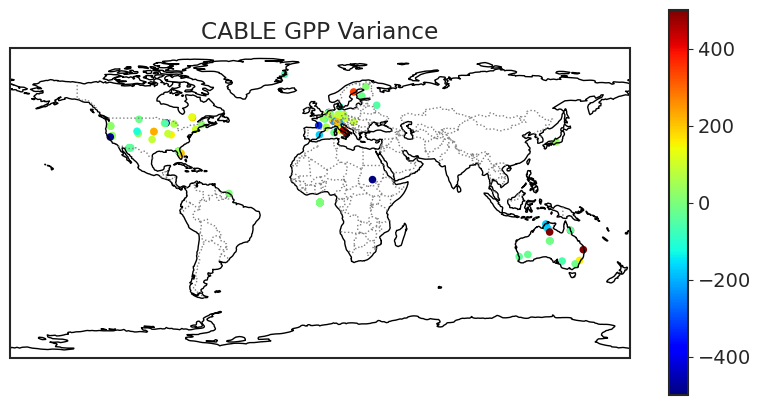

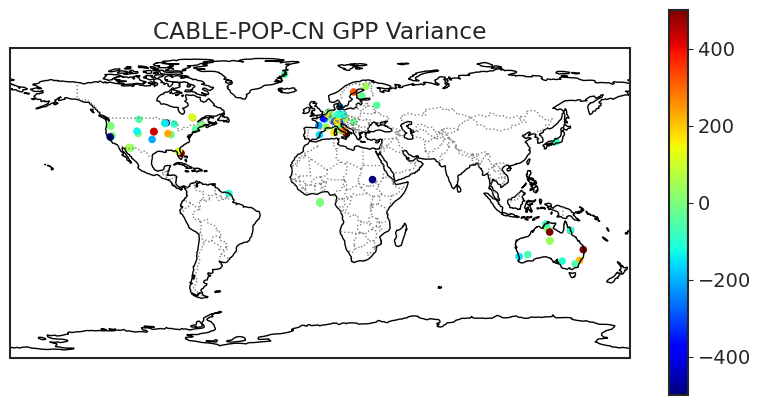

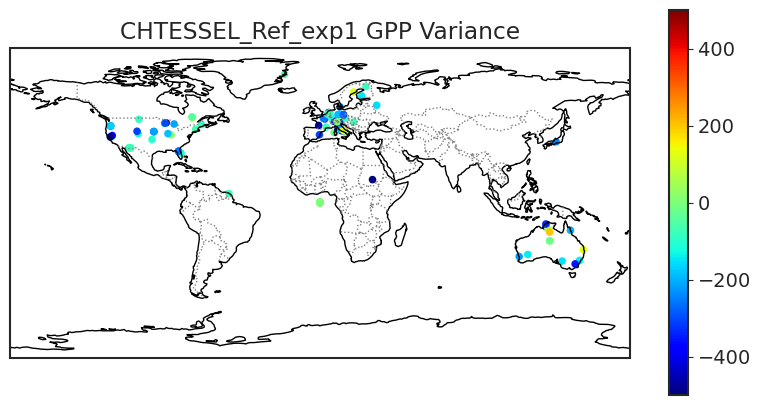

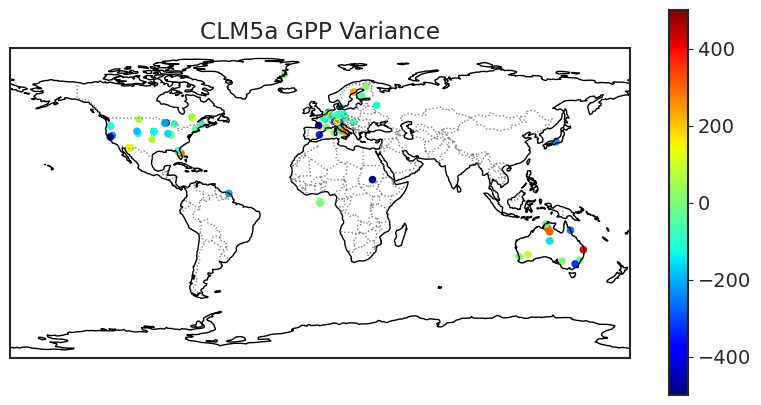

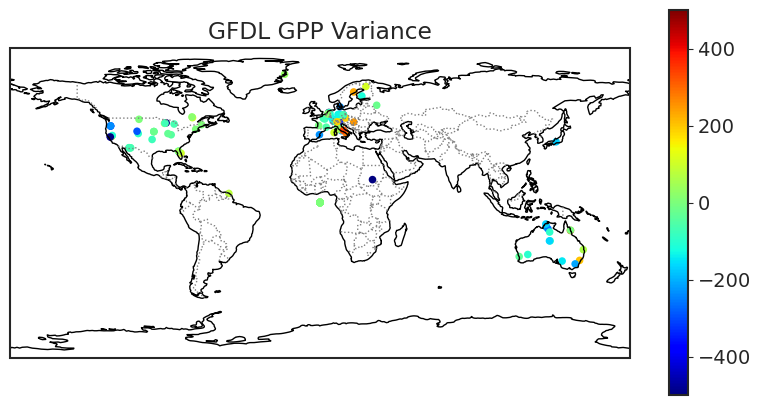

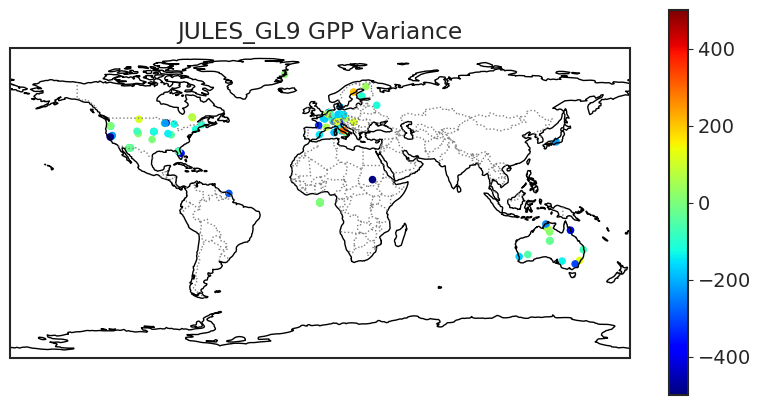

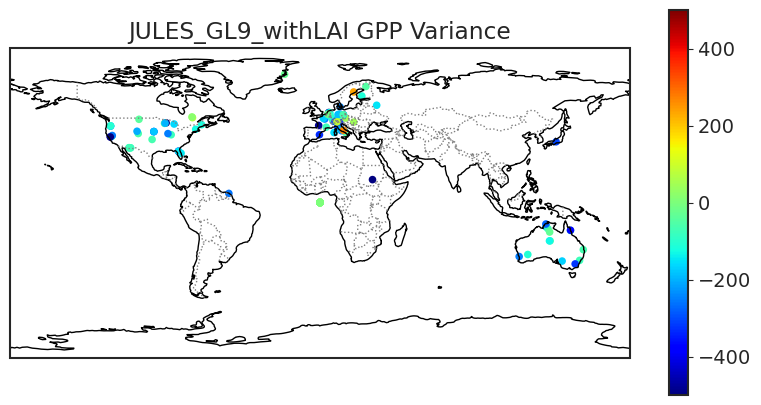

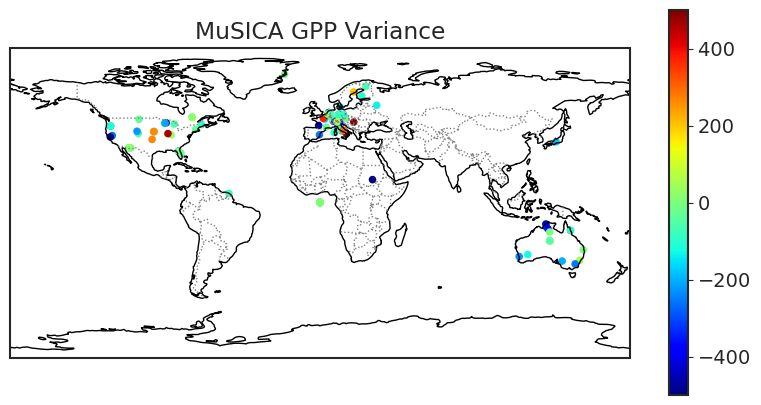

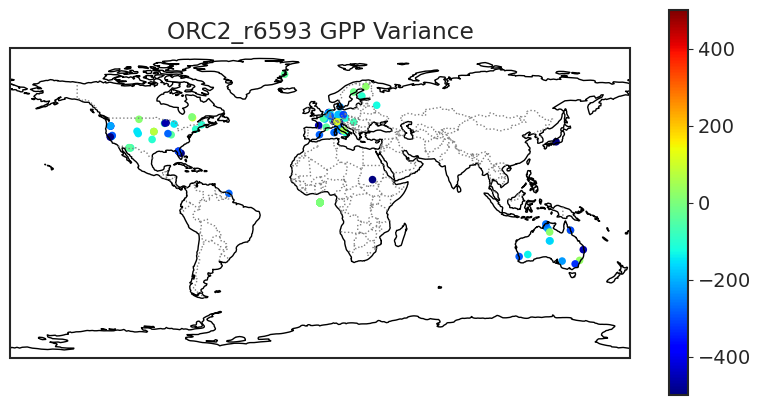

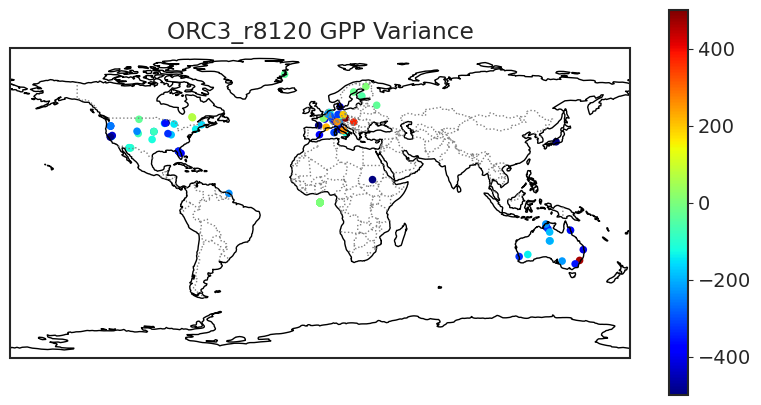

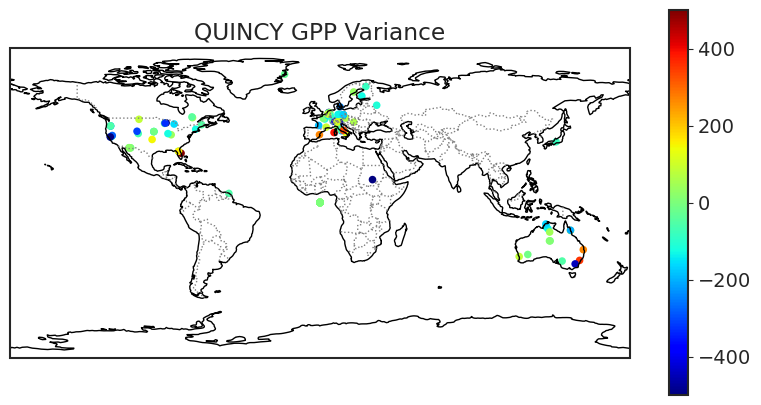

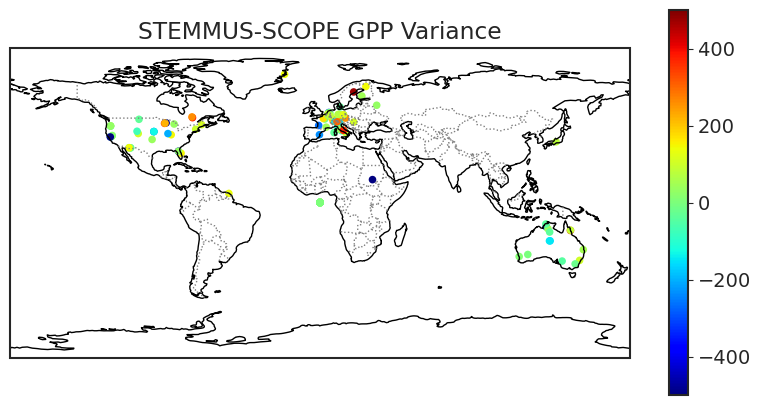

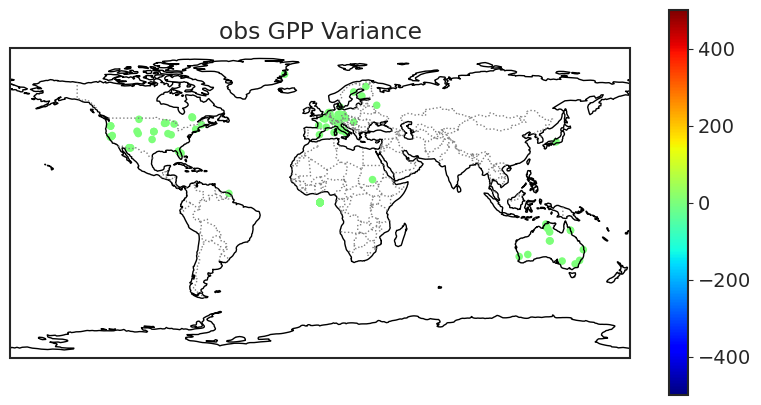

In [24]:
var_name           = 'GPP'    

PLUMBER2_path_site = "/srv/ccrc/LandAP/z5218916/script/PLUMBER2/LSM_GPP_PLUMBER2/nc_files/AR-SLu.nc"
f                  = nc.Dataset(PLUMBER2_path_site, mode='r')
model_list         = f.variables[f'{var_name}_models'][:]
model_list         = model_list.tolist()
model_list.append('obs')

for model_in in model_list:
    print(model_in)
    plot_variance(var_name, model_in, diff=True, per_LAI=False)